In [1]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.ensemble import RandomForestRegressor

pd.set_option('display.max_columns', None)

### Подготовка данных

In [49]:
# Чтение файла с тегами.
df = pd.read_excel(r'E:\Projects\portfolio\ad_creative_performance_analyzer\materials\tagging.xlsx')

In [50]:
# Колонки, которые не нужно учитывать
cols_drop = ['adtext_text','adtext_eng','headline_text','headline_eng','description_text','image_text',
             'image_eng_text','image_clip','image_clip_keywords']

df_work = df.copy()

# Очистка от сырых текстов и системных полей ---
cols_to_drop = [col for col in cols_drop if col in df_work.columns]
df_work = df_work.drop(columns = cols_drop)

### Поиск колонок с массивами

In [51]:
# Поиск множественных строк (псевдо списков) и перевод их в реальные списки
def is_text_array(val):
    # Функция, которая проверяет, является ли текст замаскированным списком
    if isinstance(val, str) and val.startswith('[') and val.endswith(']'):
        try:
            # Пробуем безопасно прочитать структуру текста
            parsed = ast.literal_eval(val)
            return isinstance(parsed, list)
        except (ValueError, SyntaxError):
            return False
    return False

# Ищем все колонки, где есть такие текстовые списки
text_array_cols = [
    col for col in df_work.columns 
    if df_work[col].dropna().apply(is_text_array).any()
    ]

# Переводим их в настоящие списки Python
for col in text_array_cols:
    # Безопасно превращаем строки "['a', 'b']" в реальные списки Python ['a', 'b']
    df_work[col] = df_work[col].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') 
        else ([] if not isinstance(x, list) else x)
    )

print(text_array_cols)

['adtext_nouns', 'adtext_verbs', 'adtext_adjs', 'headline_nouns', 'headline_verbs', 'headline_adjs', 'description_nouns', 'description_verbs', 'description_adjs', 'image_nouns', 'image_verbs', 'image_adjs', 'image_phrases', 'image_color_rest', 'image_objects', 'image_tags']


### Поиск категориальных колонок

In [53]:
# Отбираем все колонки с типом данных object или category
potential_cat_cols = df_work.select_dtypes(include=['object', 'category']).columns

# Исключаем из них те, которые уже сохранены в text_array_cols
categorical_cols = [col for col in potential_cat_cols if col not in text_array_cols]

print(categorical_cols)

['adtext_language', 'headline_language', 'cta_type', 'image_language', 'image_color_main', 'image_proportions']


### One-Hot Encoding (прямое кодирование): 
`MultiLabelBinarizer` сканирует все списки в колонке (например, `image_objects`), собирает словарь всех уникальных объектов и создает под каждый объект отдельную колонку с нулями.  
Если в текущей строке объект есть — ставит `1`.

In [55]:

# Адаптация под размер выборки
n_samples = len(df_work)
min_freq = 1 if n_samples < 30 else 3

array_cols = [col for col in list(text_array_cols) if col in df_work.columns]
    
for col in array_cols:    
    mlb = MultiLabelBinarizer()
    binary_matrix = mlb.fit_transform(df_work[col])
    
    class_counts = binary_matrix.sum(axis=0)
    valid_classes_idx = [i for i, count in enumerate(class_counts) if count >= min_freq]
    
    valid_classes = [mlb.classes_[i] for i in valid_classes_idx]
    valid_matrix = binary_matrix[:, valid_classes_idx]
    
    # Переименовываем колонки для понятности: "image_nouns -> apple"
    col_names = [f"{col} -> {cls}" for cls in valid_classes]
    df_bin = pd.DataFrame(valid_matrix, columns=col_names, index=df_work.index)
    
    df_work = pd.concat([df_work, df_bin], axis=1)
    df_work = df_work.drop(columns=[col])

### Обработка категориальных признаков (цвета, пропорции)

In [57]:
cat_cols = [col for col in list(categorical_cols) if col in df_work.columns]

for col in cat_cols:
    # get_dummies автоматически создаст нули и единицы для каждого уникального цвета
    dummies = pd.get_dummies(df_work[col], prefix=col, prefix_sep=' -> ')
    df_work = pd.concat([df_work, dummies], axis=1)
    df_work = df_work.drop(columns=[col])
    
bool_cols = df_work.select_dtypes(include=['bool']).columns
df_work[bool_cols] = df_work[bool_cols].astype(int)


In [59]:
df_work = df_work.fillna(0)
print(f'Итого в внаборе данных получилось {len(df_work.columns)} колонок')

df_work.head()

Итого в внаборе данных получилось 959 колонок


,adtext_length,adtext_contains_cta,adtext_contains_question,headline_length,headline_contains_cta,headline_contains_question,description_language,description_eng,description_length,description_contains_cta,description_contains_question,image_text_present,image_text_area,image_text_length,image_text_contains_question,image_text_contains_cta,image_people_amount,ctr,adtext_nouns -> affirmations,adtext_nouns -> app,adtext_nouns -> articles,adtext_nouns -> astrology,adtext_nouns -> blueprint,adtext_nouns -> calendar,adtext_nouns -> charts,adtext_nouns -> cycles,adtext_nouns -> destiny,adtext_nouns -> esoterics,adtext_nouns -> horizon,adtext_nouns -> horoscopes,adtext_nouns -> journey,adtext_nouns -> kind,adtext_nouns -> lifes,adtext_nouns -> lot,adtext_nouns -> moon,adtext_nouns -> natal,adtext_nouns -> nature,adtext_nouns -> personality,adtext_nouns -> phases,adtext_nouns -> rituals,adtext_nouns -> runes,adtext_nouns -> secrets,adtext_nouns -> skin,adtext_nouns -> spirituality,adtext_nouns -> step,adtext_nouns -> sunshine,adtext_nouns -> thing,adtext_nouns -> universe,adtext_nouns -> wisdom,adtext_nouns -> wisdoms,adtext_verbs -> contains,adtext_verbs -> defines,adtext_verbs -> discover,adtext_verbs -> do,adtext_verbs -> enjoy,adtext_verbs -> expands,adtext_verbs -> feel,adtext_verbs -> follow,adtext_verbs -> harmonize,adtext_verbs -> have,adtext_verbs -> introducing,adtext_verbs -> know,adtext_verbs -> learn,adtext_verbs -> love,adtext_verbs -> receive,adtext_verbs -> take,adtext_verbs -> uncover,adtext_verbs -> wanted,adtext_adjs -> ancient,adtext_adjs -> cosmic,adtext_adjs -> daily,adtext_adjs -> different,adtext_adjs -> favorite,adtext_adjs -> female,adtext_adjs -> first,adtext_adjs -> moonly,adtext_adjs -> only,adtext_adjs -> personalized,adtext_adjs -> positive,adtext_adjs -> sacred,adtext_adjs -> unique,headline_nouns -> birth,headline_nouns -> calendar,headline_nouns -> chart,headline_nouns -> cycle,headline_nouns -> magic,headline_nouns -> moon,headline_nouns -> pocket,headline_nouns -> self,headline_verbs -> decode,headline_verbs -> get,headline_verbs -> try,headline_verbs -> unveil,headline_adjs -> happiest,headline_adjs -> true,image_nouns -> abilities,image_nouns -> ability,image_nouns -> acorns,image_nouns -> acquaintances,image_nouns -> action,image_nouns -> actions,image_nouns -> activities,image_nouns -> activity,image_nouns -> affirmations,image_nouns -> age,image_nouns -> altar,image_nouns -> anxiety,image_nouns -> apple,image_nouns -> astrology,image_nouns -> attachments,image_nouns -> attention,image_nouns -> beaver,image_nouns -> birth,image_nouns -> birthday,image_nouns -> blueprint,image_nouns -> c,image_nouns -> calendar,image_nouns -> candle,image_nouns -> candles,image_nouns -> card,image_nouns -> care,image_nouns -> center,image_nouns -> challenge,image_nouns -> character,image_nouns -> charge,image_nouns -> charity,image_nouns -> chart,image_nouns -> cider,image_nouns -> cl,image_nouns -> co,image_nouns -> coffee,image_nouns -> communication,image_nouns -> control,image_nouns -> core,image_nouns -> craving,image_nouns -> creativity,image_nouns -> crystals,image_nouns -> curiosity,image_nouns -> cycle,image_nouns -> cycles,image_nouns -> day,image_nouns -> days,image_nouns -> decisions,image_nouns -> deeds,image_nouns -> deer,image_nouns -> distrust,image_nouns -> education,image_nouns -> emotions,image_nouns -> energy,image_nouns -> enhances,image_nouns -> fear,image_nouns -> flower,image_nouns -> fn,image_nouns -> fr,image_nouns -> friends,image_nouns -> fruit,image_nouns -> future,image_nouns -> gemini,image_nouns -> good,image_nouns -> gratitude,image_nouns -> guide,image_nouns -> guilt,image_nouns -> h,image_nouns -> harvest,image_nouns -> heart,image_nouns -> help,image_nouns -> hints,image_nouns -> hobby,image_nouns -> holidays,image_nouns -> home,image_nouns -> house,image_nouns -> hunters,image_nouns -> illusions,image_nouns -> incense,image_nouns -> intention,image_nouns -> intuition,image_nou

### Обучение модели Random Forest

In [60]:
X = df_work.drop(columns=['ctr'])
y = df_work['ctr']

rf = RandomForestRegressor(
    n_estimators=100, 
    max_depth=3 if n_samples < 30 else None, 
    random_state=42
)
rf.fit(X, y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Расчет важности признаков

In [61]:

importances = rf.feature_importances_
imp_df = pd.DataFrame({'feature': X.columns, 'importance': importances})
imp_df['importance_pct'] = (imp_df['importance'] / imp_df['importance'].sum()) * 100
imp_df = imp_df.sort_values(by='importance_pct', ascending=False).reset_index(drop=True)

imp_df

,feature,importance,importance_pct
0,image_text_length,0.191375,19.137466
1,image_verbs -> feel,0.098911,9.891067
2,image_proportions -> 2048x1152,0.069009,6.900883
3,image_nouns -> energy,0.033317,3.331702
4,image_tags -> poster,0.023171,2.317130
...,...,...,...
953,image_color_main -> #993333,0.000000,0.000000
954,description_eng,0.000000,0.000000
955,description_language,0.000000,0.000000
956,headline_contains_question,0.000000,0.000000


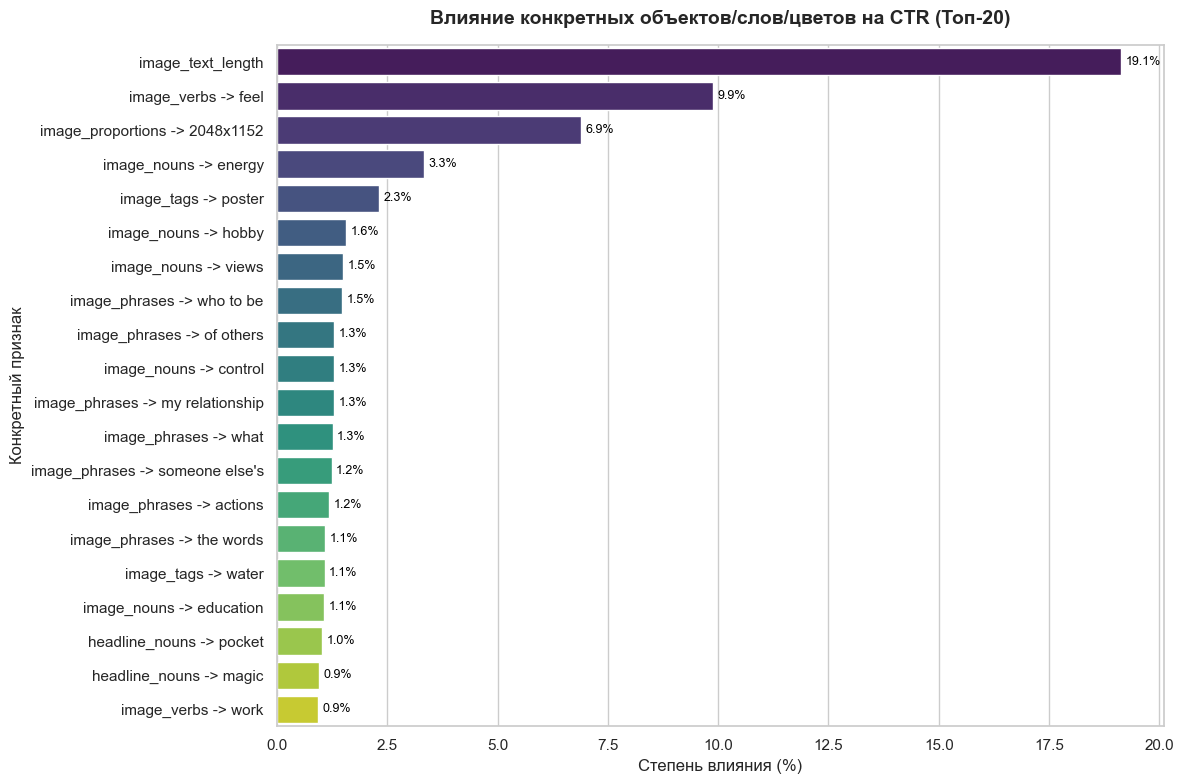

In [62]:
# 6. Визуализация ТОП-20 самых важных конкретных значений

plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")
top_df = imp_df.head(20).copy()

ax = sns.barplot(x='importance_pct', y='feature', data=top_df, palette='viridis', hue='feature', legend=False)
plt.title('Влияние конкретных объектов/слов/цветов на CTR (Топ-20)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Степень влияния (%)', fontsize=12)
plt.ylabel('Конкретный признак', fontsize=12)

for p in ax.patches:
    w = p.get_width()
    ax.annotate(f'{w:.1f}%', (w + 0.1, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=9, color='black')
                
plt.tight_layout()
plt.show()